# Part 3 : Baseline Anomaly Detection with Z-score

This notebook aims to:
1. Build a simple and explainable baseline.
2. Detecting anomalies using statistical deviations.
3. Compare between :
- Z-score of raw time-series data
- Z-score of STL residuals
4. Evaluate using ground-truth labels.
  

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import precision_score,recall_score,f1_score
plt.style.use("seaborn-v0_8")

In [5]:
df = pd.read_csv("data/raw/A1Benchmark/real_1_processed.csv")
df.head()

,timestamp,value,is_anomaly,value_scaled,trend,seasonal,residual
0,1,0.000000,0,-1.260231,0.453513,-1.318483,-0.395261
1,2,0.091758,0,0.190651,0.431449,-0.157560,-0.083238
2,3,0.172297,0,1.464135,0.409611,0.819659,0.234865
3,4,0.226219,0,2.316762,0.388036,1.192424,0.736301
4,5,0.176358,0,1.528351,0.366754,0.928259,0.233339


In [6]:
df["zscore_raw"] = zscore(df["value"])

In [7]:
df["zscore_residual"] = zscore(df["residual"])

## Validation-Based Threshold Selection

Instead of using a fixed heuristic threshold, we select the anomaly threshold based on validation performance. Since the Yahoo S5 dataset provides ground-truth labels, we sweep a range of Z-score thresholds and select the one that maximizes the F1-score.

In [15]:
thresholds = np.linspace(2.0,4.0,50)
f1_scores = []
for t in thresholds:
    preds = (np.abs(df["zscore_residual"]) > t).astype(int)
    output = f1_score(df["is_anomaly"],preds)
    f1_scores.append(output)
best_threshold = thresholds[np.argmax(f1_scores)]
best_threshold

np.float64(4.0)

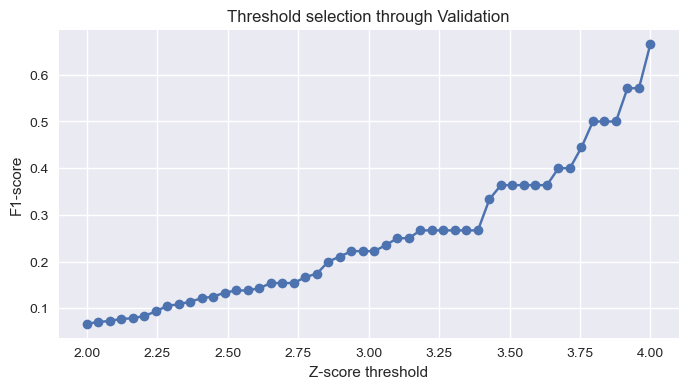

In [16]:
plt.figure(figsize=(8,4))
plt.plot(thresholds, f1_scores, marker="o")
plt.xlabel("Z-score threshold")
plt.ylabel("F1-score")
plt.title("Threshold selection through Validation")
plt.show()

In [17]:
df["pred_residual"] = (np.abs(df["zscore_residual"]) > best_threshold).astype(int)
df["pred_raw"] = (np.abs(df["zscore_raw"]) > best_threshold).astype(int)

## Evaluation Metrics

We evaluate anomaly detection performance using precision, recall, and F1-score.

In [18]:
y_true = df["is_anomaly"]
metrics = {"Raw Z-score": {"precision": precision_score(y_true,df["pred_raw"]),
                           "recall": recall_score(y_true, df["pred_raw"]),
                           "f1": f1_score(y_true, df["pred_raw"])},
           "Residual Z-score": {"precision": precision_score(y_true,df["pred_residual"]),
                           "recall": recall_score(y_true, df["pred_residual"]),
                           "f1": f1_score(y_true, df["pred_residual"])} }
pd.DataFrame(metrics).T

,precision,recall,f1
Raw Z-score,0.333333,1.0,0.500000
Residual Z-score,0.500000,1.0,0.666667


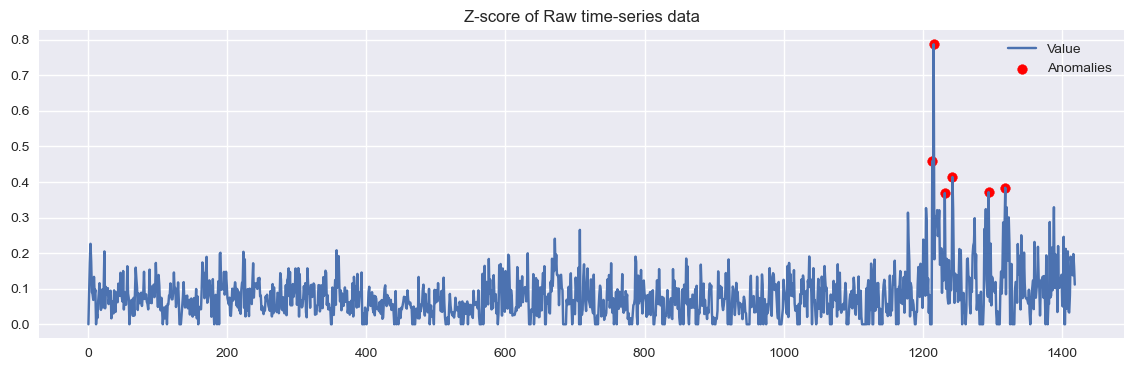

In [21]:
plt.figure(figsize=(14,4))
plt.plot(df["value"], label="Value")
plt.scatter(df.index[df["pred_raw"] == 1], df["value"][df["pred_raw"] == 1],
            color="red", label="Anomalies")
plt.title("Z-score of Raw time-series data")
plt.legend()
plt.show()

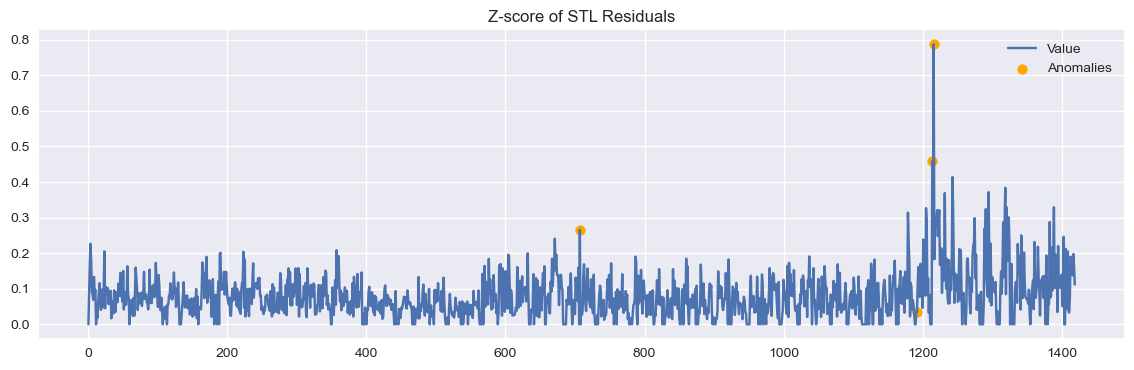

In [22]:
plt.figure(figsize=(14,4))
plt.plot(df["value"], label="Value")
plt.scatter(df.index[df["pred_residual"] == 1],df["value"][df["pred_residual"] == 1],
            color="orange",label="Anomalies")
plt.title("Z-score of STL Residuals")
plt.legend()
plt.show()